# Chapter 11 & 12: Backtesting Dangers & CSCV

**AFML Ch. 11-12** -- Detecting overfitting in backtests.

When you test many strategies on the same data, the best in-sample
performer is likely overfit. This notebook shows how to quantify that
risk using Probability of Backtest Overfitting (PBO) and
Combinatorially Symmetric Cross-Validation (CSCV), and how to correct
for multiple testing with Bonferroni and Holm adjustments.

This notebook demonstrates:

- Probability of Backtest Overfitting (PBO)
- Combinatorially Symmetric Cross-Validation (CSCV)
- Bonferroni and Holm corrections for multiple testing
- Overfitting simulation with increasing strategy count

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymlfinance

%matplotlib inline
np.random.seed(42)

## Generate Synthetic Strategy Returns

We create 10 strategies: most are pure noise, but strategy 0 has a
small positive drift and strategy 1 has a larger drift with higher
volatility.

In [2]:
n_periods = 500
n_strategies = 10

# Mostly noise strategies, with 1-2 having slight edge
returns_matrix = np.random.randn(n_periods, n_strategies) * 0.01
# Give strategy 0 a slight edge
returns_matrix[:, 0] += 0.0005
# Give strategy 1 a larger edge but more volatile
returns_matrix[:, 1] += 0.001
returns_matrix[:, 1] *= 2.0

print(f"Generated {n_strategies} strategy returns over {n_periods} periods")
for i in range(n_strategies):
    sr = pymlfinance.backtesting.sharpe_ratio(returns_matrix[:, i])
    print(f"  Strategy {i}: Sharpe = {sr:.4f}")

Generated 10 strategy returns over 500 periods
  Strategy 0: Sharpe = 0.8820
  Strategy 1: Sharpe = 1.7969
  Strategy 2: Sharpe = 0.0797
  Strategy 3: Sharpe = -0.5292
  Strategy 4: Sharpe = -0.1013
  Strategy 5: Sharpe = -0.0084
  Strategy 6: Sharpe = -0.8699
  Strategy 7: Sharpe = 0.0637
  Strategy 8: Sharpe = 0.7742
  Strategy 9: Sharpe = 1.1958


## Probability of Backtest Overfitting (PBO)

PBO estimates the probability that the best in-sample strategy will
underperform out-of-sample. A high PBO (close to 1) means the backtest
is likely overfit.

In [3]:
pbo = pymlfinance.backtesting.probability_of_backtest_overfitting(
    returns_matrix, num_partitions=10, seed=42
)
print(f"PBO = {pbo:.4f}")
print(f"Interpretation: {pbo:.0%} chance that the best IS strategy")
print(f"underperforms OOS")

PBO = 0.0040
Interpretation: 0% chance that the best IS strategy
underperforms OOS


## CSCV Analysis

Combinatorially Symmetric Cross-Validation partitions the data into
groups and exhaustively tests all train/test splits. The rank logits
measure how the best IS strategy ranks OOS.

In [4]:
cscv_result = pymlfinance.backtesting.cscv(returns_matrix, num_groups=8)
print(f"PBO (via CSCV): {cscv_result.pbo:.4f}")
print(f"Rank logits: [{', '.join(f'{x:.3f}' for x in cscv_result.rank_logits[:5])}...]")

PBO (via CSCV): 0.0571
Rank logits: [-2.303, -2.303, -2.303, -2.303, -2.303...]


### Visualisation: PBO and Rank Logit Distribution

The histogram of rank logits shows the distribution of out-of-sample
performance for the best in-sample strategy. Negative logits indicate
the strategy performed worse than median OOS (i.e., overfitting).

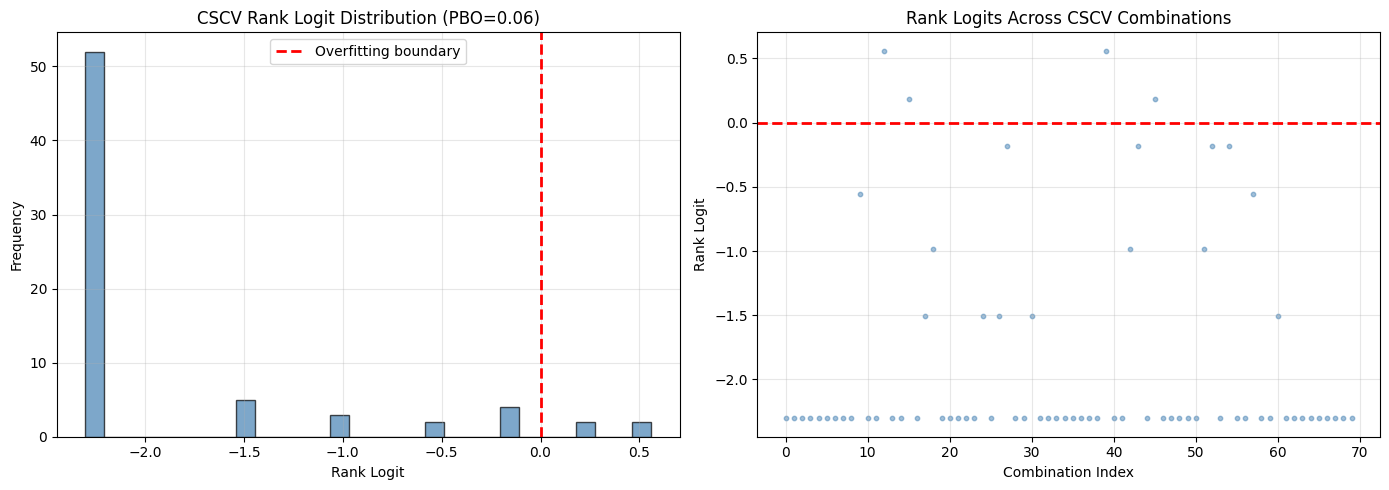

In [5]:
rank_logits = np.array(cscv_result.rank_logits)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of rank logits
axes[0].hist(rank_logits, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].axvline(0, color="red", linestyle="--", linewidth=2, label="Overfitting boundary")
axes[0].set_xlabel("Rank Logit")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"CSCV Rank Logit Distribution (PBO={cscv_result.pbo:.2f})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Scatter of rank logits
axes[1].scatter(range(len(rank_logits)), rank_logits, alpha=0.5, s=10, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Combination Index")
axes[1].set_ylabel("Rank Logit")
axes[1].set_title("Rank Logits Across CSCV Combinations")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Multiple Testing Corrections

When testing many strategies, some will appear significant by chance.
Bonferroni and Holm corrections adjust p-values to control the
family-wise error rate. Bonferroni is more conservative; Holm is
a step-down method with better statistical power.

In [6]:
# Simulate p-values from testing multiple strategies
p_values = np.random.uniform(0, 1, n_strategies)
p_values[0] = 0.01  # one genuinely significant
p_values[1] = 0.04  # borderline

bonferroni = pymlfinance.backtesting.bonferroni_correction(p_values)
holm = pymlfinance.backtesting.holm_correction(p_values)

print(f"{'Strategy':>10} {'Raw p':>10} {'Bonferroni':>12} {'Holm':>10} {'Sig (5%)':>10}")
for i in range(n_strategies):
    sig = "Yes" if holm[i] < 0.05 else "No"
    print(f"{f'Strat {i}':>10} {p_values[i]:>10.4f} {bonferroni[i]:>12.4f} {holm[i]:>10.4f} {sig:>10}")

  Strategy      Raw p   Bonferroni       Holm   Sig (5%)
   Strat 0     0.0100       0.1000     0.1000         No
   Strat 1     0.0400       0.4000     0.3600         No
   Strat 2     0.4607       1.0000     1.0000         No
   Strat 3     0.2863       1.0000     1.0000         No
   Strat 4     0.2475       1.0000     1.0000         No
   Strat 5     0.6452       1.0000     1.0000         No
   Strat 6     0.6510       1.0000     1.0000         No
   Strat 7     0.8245       1.0000     1.0000         No
   Strat 8     0.4177       1.0000     1.0000         No
   Strat 9     0.0731       0.7309     0.5847         No


### Visualisation: P-Value Comparison

A grouped bar chart comparing raw, Bonferroni-adjusted, and
Holm-adjusted p-values for each strategy. The red dashed line marks the
5% significance threshold.

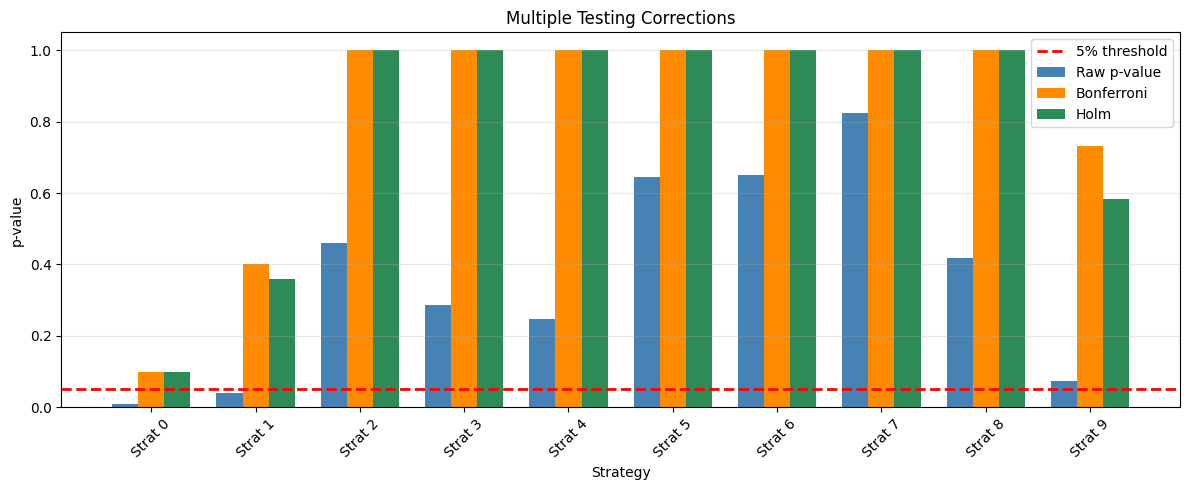

In [7]:
x = np.arange(n_strategies)
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width, p_values, width, label="Raw p-value", color="steelblue")
ax.bar(x, np.minimum(bonferroni, 1.0), width, label="Bonferroni", color="darkorange")
ax.bar(x + width, np.minimum(holm, 1.0), width, label="Holm", color="seagreen")
ax.axhline(0.05, color="red", linestyle="--", linewidth=2, label="5% threshold")
ax.set_xlabel("Strategy")
ax.set_ylabel("p-value")
ax.set_title("Multiple Testing Corrections")
ax.set_xticks(x)
ax.set_xticklabels([f"Strat {i}" for i in range(n_strategies)], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Overfitting Simulation

As the number of noise strategies increases, the best in-sample Sharpe
ratio inflates (selection bias). PBO should also trend upward,
confirming that the selected strategy is increasingly likely to be
overfit.

In [8]:
print("Testing with increasing number of strategies:")
n_strats_list = [2, 5, 10, 20, 50]
best_srs = []
pbo_vals = []

for n_strats in n_strats_list:
    # All noise strategies
    noise_returns = np.random.randn(n_periods, n_strats) * 0.01
    best_sr = max(pymlfinance.backtesting.sharpe_ratio(noise_returns[:, i])
                  for i in range(n_strats))
    best_srs.append(best_sr)
    if n_strats >= 4:
        pbo_val = pymlfinance.backtesting.probability_of_backtest_overfitting(
            noise_returns, num_partitions=min(n_strats, 10), seed=42
        )
        pbo_vals.append(pbo_val)
        print(f"  {n_strats:>3d} strategies: best SR = {best_sr:.4f}, PBO = {pbo_val:.4f}")
    else:
        pbo_vals.append(None)
        print(f"  {n_strats:>3d} strategies: best SR = {best_sr:.4f}, PBO = N/A (need >=4)")

Testing with increasing number of strategies:
    2 strategies: best SR = -0.5567, PBO = N/A (need >=4)
    5 strategies: best SR = 1.1124, PBO = 0.0000
   10 strategies: best SR = 0.6851, PBO = 0.8889
   20 strategies: best SR = 1.2942, PBO = 0.6944
   50 strategies: best SR = 1.3290, PBO = 0.7024


## Exercises

1. Add strategies with genuine alpha and see if PBO decreases.
2. Vary the number of CSCV partitions and observe stability.
3. Compare Bonferroni (conservative) vs Holm (less conservative) power.